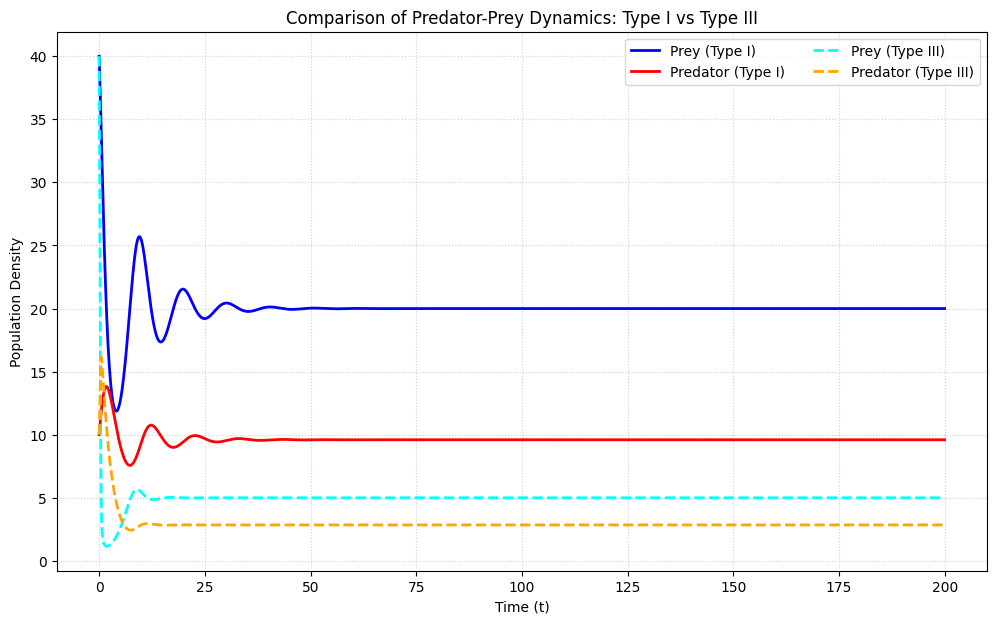

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def model_type_i(y, t, r, K, alpha, e, gamma):
    N, P = y
    dNdt = r * N * (1 - N/K) - alpha * N * P
    dPdt = e * alpha * N * P - gamma * P
    return [dNdt, dPdt]

def model_type_iii(y, t, r, K, alpha, a, e, gamma):
    N, P = y
    functional_response = (alpha * N**2) / (1 + a * N**2)
    dNdt = r * N * (1 - N/K) - functional_response * P
    dPdt = e * functional_response * P - gamma * P
    return [dNdt, dPdt]


r = 1.2      
K = 100.0  
alpha = 0.1 
a = 0.01    
e = 0.2     
gamma = 0.4 
t = np.linspace(0, 200, 2000)
y0 = [40, 10]

sol_i = odeint(model_type_i, y0, t, args=(r, K, alpha, e, gamma))
sol_iii = odeint(model_type_iii, y0, t, args=(r, K, alpha, a, e, gamma))

plt.figure(figsize=(12, 7))
plt.plot(t, sol_i[:, 0], color='blue', linestyle='-', linewidth=2, label='Prey (Type I)')
plt.plot(t, sol_i[:, 1], color='red', linestyle='-', linewidth=2, label='Predator (Type I)')
plt.plot(t, sol_iii[:, 0], color='cyan', linestyle='--', linewidth=2, label='Prey (Type III)')
plt.plot(t, sol_iii[:, 1], color='orange', linestyle='--', linewidth=2, label='Predator (Type III)')
plt.title('Comparison of Predator-Prey Dynamics: Type I vs Type III')
plt.xlabel('Time (t)')
plt.ylabel('Population Density')
plt.legend(loc='best', ncol=2)
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('combined_comparison.png', dpi=300)
plt.show()